<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Use Natural Language to Create Charts and Graphs**
## **Build Your Own Data Visualization Agent**


Estimated time needed: **30** minutes


## Overview


Imagine you are a data analyst or a data scientist of a marketing team at an e-commerce company. The company needs to understand customer purchasing behaviors over the last year to tailor their upcoming holiday campaigns. Traditionally, this would involve complex SQL queries, data wrangling in Python, and perhaps building visual dashboards to interpret the results including analyzing spreadsheets, creating charts, and maybe even some statistical analysis—tasks that require considerable time and expertise.

With the integration of Langchain and LLMs, you can simply ask, "Show me a visualization of monthly sales trends by product category," or "Generate a heatmap of customer activity by region." The system would use the `create_pandas_dataframe_agent` to process the CSV data, and then dynamically generate visualizations such as line graphs, bar charts, or heatmaps in response to these queries. This not only speeds up the data analysis process but also allows team members who may not be tech-savvy to engage directly with the data and make informed decisions quickly. This approach fosters a more collaborative environment and ensures that strategic decisions are backed by real-time data insights, visually represented for easy comprehension.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/V_7__WU_jHJ1lOpTeSLxTQ/chat%20with%20data.png" width="50%" alt="indexing"/>


In this lab, you will learn how to seamlessly integrate data visualization into your conversational data analysis using Langchain and LLMs. Starting with CSV file data, you will use the `create_pandas_dataframe_agent` to build an interactive agent that not only understands and responds to your queries but also translates data responses into visual formats. You will explore how to dynamically generate charts, graphs, and heatmaps directly in response to natural language questions. This capability will enable you to visualize trends, compare figures, and spot patterns immediately, making your data analysis workflow both efficient and visually engaging. By the end of this project, you will have the skills to create a data conversational agent that acts as both analyst and visualizer, bringing data to life through dialogue.

In this lab, you are going to use OpenRouter platform with your preferred LLM.


---------


## __Table of contents__

<ol>
    <li><a href="#Overview">Overview</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-required-libraries">Installing required libraries</a></li>
            <li><a href="#Importing-required-libraries">Importing required libraries</a></li>
        </ol>
    </li>
    <li>
        <a href="#Data-set">Data set</a>
        <ol>
            <li><a href="#Load-the-data-set">Load the data set</a></li>
        </ol>
    </li>
    <li>
        <a href="#Load-LLM">Load LLM</a>
        <ol>
            <li><a href="#Talk-to-your-data">Talk to your data</a></li>
            <li><a href="#Plot-your-data-with-natural-language">Plot your data with natural language</a></li>
        </ol>
    </li>
</ol>

<a href="#Exercises">Exercises</a>
<ol>
    <li><a href="#Exercise-1---Relationship-between-parental-education-level-and-student-grades">Exercise 1. Relationship between parental education level and student grades</a></li>
    <li><a href="#Exercise-2---Impact-of-internet-access-at-home-on-grades">Exercise 2. Impact of internet access at home on grades</a></li>
    <li><a href="#Exercise-3---Explore-LLM's-code">Exercise 3. Explore LLM's code</a></li>
</ol>


## Objectives


After completing the project, you should be able to:

- **Use LangChain with large language models**: Understand and apply the Langchain framework in conjunction with LLMs to interact with and analyze data stored in CSV files through natural language processing.
- **Create conversational data agents**: Build a conversational agent that can understand and respond to natural language queries about data, enabling users to ask questions directly and receive immediate answers.
- **Implement data visualization through dialogue**: Integrate data visualization tools within your conversational agent, allowing you to request and generate visual data representations such as graphs, charts, and heatmaps dynamically based on your queries.
- **Enhance decision-making process**: Develop the capability to derive actionable insights from data via interactive dialogues and visual outputs, thereby improving the decision-making process and making data analysis accessible to non-technical stakeholders.


----


## Setup


This project is based on Jupyter Notebook. If you're not familiar with it, here's a quick guide on how to run code within it:

A Jupyter Notebook consists of cells. To execute a code cell, click on the cell that you want to run and click the 'Run' button, as shown in the picture.


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IwbhiH3Wwv-VK-J4rioTAw/run.png" width="50%" alt="indexing"/>


For this lab, you will be using the following libraries:

*   [`ibm-watson-ai`](https://ibm.github.io/watson-machine-learning-sdk/index.html) for using LLMs from IBM's watsonx.ai.
*   [`LangChain`, `langchain-ibm`, `langchain-experimental`](https://www.langchain.com/) for using its agent function to interact with data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.


### Installing required libraries

The following required libraries are __not__ preinstalled in the Skills Network Labs environment. __You must run the following cell__ to install them:

**Note:** The version has been pinned here. It's recommended that you do this as well. Even if the library is updated in the future, the installed library could still support this lab work.

This might take approximately 1-2 minutes. 

As you use `%%capture` to capture the installation, you won't see the output process. But after the installation completes, you will see a number beside the cell.


In [ ]:
# %%capture
# !pip install --user "ibm-watsonx-ai==0.2.6"
# !pip install --user "langchain==0.1.16" 
# !pip install --user "langchain-ibm==0.1.4"
# !pip install --user "langchain-experimental==0.0.57"
# !pip install --user "matplotlib==3.8.4"
# !pip install --user "seaborn==0.13.2"

After you installat the libraries, restart your kernel. You can do that by clicking the **Restart the kernel** icon.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/build-a-hotdog-not-hotdog-classifier-guided-project/images/Restarting_the_Kernel.png" width="50%" alt="Restart kernel">


### Importing required libraries

_It is recommended that you import all required libraries in one place (here):_


In [1]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

import matplotlib.pyplot as plt
import pandas as pd


## Dataset


In this lab, you will work on the Student Alcohol Consumption data set `student-mat.csv` by UCI Machine Learning as an example. For more information, see [Kaggle](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption). It is based on data collected from two secondary schools in Portugal. The students included in the survey were in mathematics and Portuguese courses.


The dataset you are using is for the mathematics course. The number of mathematics students involved in the collection was 395. The data collected in locations such as Gabriel Pereira and Mousinho da Silveira includes several pertinent values. Examples of such data are records of demographic information, grades, and alcohol consumption.


| Field     | Description                                                                 |
|-----------|-----------------------------------------------------------------------------|
| school    | GP/MS for the student's school                                              |
| sex       | M/F for gender                                                              |
| age       | 15-22 for the student's age                                                 |
| address   | U/R for urban or rural, respectively                                        |
| famsize   | LE3/GT3 for less than or greater than three family members                  |
| Pstatus   | T/A for living together or apart from parents, respectively                 |
| Medu      | 0 (none) / 1 (primary-4th grade) / 2 (5th - 9th grade) / 3 (secondary) / 4 (higher) for mother's education |
| Fedu      | 0 (none) / 1 (primary-4th grade) / 2 (5th - 9th grade) / 3 (secondary) / 4 (higher) for father's education |
| Mjob      | 'teacher,' 'health' care related, civil 'services,' 'at_home' or 'other' for the student's mother's job |
| Fjob      | 'teacher,' 'health' care related, civil 'services,' 'at_home' or 'other' for the student's father's job |
| reason    | reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other') |
| guardian  | mother/father/other as the student's guardian                               |
| traveltime| 1 (<15mins) / 2 (15 - 30 mins) / 3 (30 mins - 1 hr) / 4 (>1hr) for a time from home to school |
| studytime | 1 (<2hrs) / 2 (2 - 5hrs) / 3 (5 - 10hrs) / 4 (>10hrs) for weekly study time |
| failures  | 1-3/4 for the number of class failures (if more than three, then record 4)  |
| schoolsup | yes/no for extra educational support                                        |
| famsup    | yes/no for family educational support                                       |
| paid      | yes/no for extra paid classes for Math or Portuguese                        |
| activities| yes/no for extra-curricular activities                                      |
| nursery   | yes/no for whether attended nursery school                                  |
| higher    | yes/no for the desire to continue studies                                   |
| internet  | yes/no for internet access at home                                          |
| romantic  | yes/no for relationship status                                              |
| famrel    | 1-5 scale on quality of family relationships                                |
| freetime  | 1-5 scale on how much free time after school             |
| goout     | 1-5 scale on how much student goes out with friends      |
| Dalc      | 1-5 scale on how much alcohol consumed on weekdays       |
| Walc      | 1-5 scale on how much alcohol consumed on the weekend    |
| health    | 1-5 scale on health condition                            |
| absences  | 0-93 number of absences from school                      |
| G1        | 0-20 for the first-period grade                          |
| G2        | 0-20 for the second-period grade                         |
| G3        | 0-20 for the final grade                                 |


### Load the data set


Execute the code in the following cell to load your dataset. This code reads the CSV file into a pandas DataFrame, making the data accessible for processing in Python.


In [2]:
# df = pd.read_csv(
#     "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZNoKMJ9rssJn-QbJ49kOzA/student-mat.csv"
# )


df = pd.read_csv("student-mat.csv")

Let's examine the first five rows of the dataset to get a glimpse of the data structure and its contents.


In [3]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


You can also review the detailed information for each column in the dataset, focusing on the presence of null values and the specific data types of each column.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## Load LLM


Execute the code in the cell below to load the llama-3-405b LLM model from watsonx.ai. 

Additionally, you will configure the LLM to interact with data by integrating it with Langchain's `create_pandas_dataframe_agent`.


### API Credentials

You are configured to run this locally! Your credentials will be loaded from your `.env` file.


In [ ]:
import httpx
from langchain_openai import ChatOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

# Load environment variables
load_dotenv()

api_key = os.getenv("OPENROUTER_API_KEY")
base_url = os.getenv("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1")
model_id = os.getenv("MODEL_ID", "openai/gpt-4o-mini")

llm = ChatOpenAI(
    api_key=api_key,
    base_url=base_url,
    model=model_id,
    temperature=0,
    http_client=httpx.Client(verify=False)
)

agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=True,
    allow_dangerous_code=True,
    return_intermediate_steps=True,
    max_iterations=10,
    agent_executor_kwargs={"handle_parsing_errors": True},
)

def ask_df(question: str, verbose: bool=True):
    result = agent.invoke({"input": question})

    output = result.get("output", "")
    if output:
        return result

    if verbose:
        steps = result.get("intermediate_steps", [])
        if steps:
            last_action = steps[-1][0]

            if getattr(last_action, "tool", None) == "_Exception":
                fallback = getattr(last_action, "log", "")
                if fallback:
                    result["output"] = fallback

    return result

### Interact with your data


Let's start with a simple interaction.

Ask LLM how many rows of data are in the CSV file.


In [12]:
response = ask_df("how many rows of data are in this file?")



> Entering new AgentExecutor chain...
Thought: I need to count the number of rows in the dataframe `df`.

Action: python_repl_ast
Action Input: df.shape[0]395The dataframe `df` contains 395 rows of data.

Final Answer: 395

> Finished chain.


In [13]:
response['output']

'395'

From the output above, the model reports that there are 395 rows of data in the file.


Let's verify this count using Python code to ensure accuracy.


In [8]:
len(df)

395

The row count matches and is correct! 


Curious about the code the LLM generated and used to create this result?

Run the code in the cell below to reveal the underlying commands.


Surprisingly, the LLM uses the same code as you do.


Also, you could let LLM return some data that you are looking for based on the CSV file.


In [14]:
response = ask_df("Give me all the data where student's age is over 18 years old.")



> Entering new AgentExecutor chain...
Thought: We need to filter the dataframe to only include rows where the 'age' column is greater than 18.

Action: python_repl_ast
Action Input: df[df['age'] > 18]    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
127     GP   F   19       U     GT3       T     0     1   at_home     other   
153     GP   M   19       U     GT3       T     3     2  services   at_home   
210     GP   F   19       U     GT3       T     3     3     other     other   
247     GP   M   22       U     GT3       T     3     1  services  services   
257     GP   M   19       U     LE3       A     4     3  services   at_home   
270     GP   F   19       U     GT3       T     3     3     other  services   
296     GP   F   19       U     GT3       T     4     4    health     other   
304     GP   M   19       U     GT3       T     3     3     other     other   
306     GP   M   20       U     GT3       A     3     2  services     other   
307     

In [15]:
print(response)

{'input': "Give me all the data where student's age is over 18 years old.", 'output': 'The filtered dataframe contains 34 rows with student ages over 18 years old.', 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="df[df['age'] > 18]", log="Thought: We need to filter the dataframe to only include rows where the 'age' column is greater than 18.\n\nAction: python_repl_ast\nAction Input: df[df['age'] > 18]"),     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
127     GP   F   19       U     GT3       T     0     1   at_home     other   
153     GP   M   19       U     GT3       T     3     2  services   at_home   
210     GP   F   19       U     GT3       T     3     3     other     other   
247     GP   M   22       U     GT3       T     3     1  services  services   
257     GP   M   19       U     LE3       A     4     3  services   at_home   
270     GP   F   19       U     GT3       T     3     3     other  services   
296     GP   F

Let's get the code LLM used for charting this plot.


### Plot your data with natural language


#### Task 1
Generating a first visual on the data set to know the total number of male and female students in the data set.

You just need to tell the agent that "Plot the gender count with bars."




> Entering new AgentExecutor chain...
Thought: We need to count the number of males and females in the dataset and then create a bar chart to visualize the results.

Action: python_repl_ast
Action Input: df['sex'].value_counts().plot(kind='bar')Axes(0.125,0.11;0.775x0.77)The bar chart has been generated, showing the count of males and females in the dataset. The x-axis represents the genders (F for female, M for male), and the y-axis shows the count of each gender.

Action: python_repl_ast
Action Input: plt.show()NameError: name 'plt' is not definedThe error message indicates that the 'plt' module, which is typically used for plotting in Python, has not been imported. To fix this, we need to import the 'matplotlib.pyplot' module, commonly referred to as 'plt'.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt

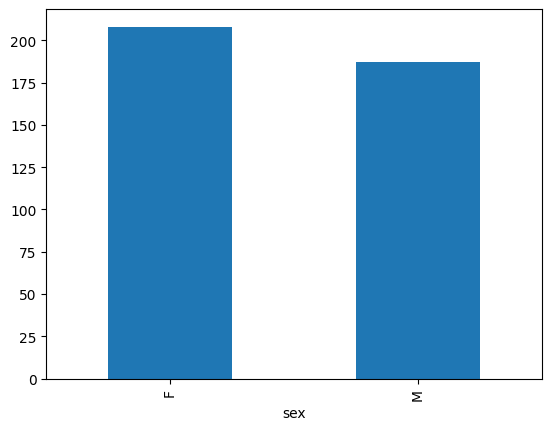

The 'matplotlib.pyplot' module has been successfully imported and is now accessible via the 'plt' alias. We can now use 'plt.show()' to display the bar chart.

Action: python_repl_ast
Action Input: plt.show()The bar chart has been displayed, showing the count of males and females in the dataset. The chart visually represents the gender distribution in the data.

Final Answer: The bar chart has been generated and displayed, providing a visual representation of the gender count in the dataset.

> Finished chain.


In [16]:
response = ask_df("Generate a bar chart to plot the gender count.")

Let's see what code the LLM generated for ploting this chart.


#### Task 2

Generating a pie chart to display the average value of weekend alcohol for each gender in the dataset.

You will use the prompt "Generate a pie chart to display the average value of Walc for each gender."

You may notice that the model generates two charts. The charts indicate the progressive improvement of the agent's code as it searches for the best way to answer your prompt, which improves the response to your query.




> Entering new AgentExecutor chain...
Thought: To generate a pie chart showing the average walking time (Walc) for each gender, we need to first calculate the average Walc for males and females separately, then plot these values as a pie chart.

Action: python_repl_ast
Action Input: df.groupby('sex')['Walc'].mean().plot.pie()Axes(0.22375,0.11;0.5775x0.77)The pie chart has been generated, but it's not displayed in the abbreviated output. To actually see the pie chart, we need to add a display command.

Action: python_repl_ast
Action Input: %matplotlib inline; df.groupby('sex')['Walc'].mean().plot.pie()SyntaxError: invalid syntax (<unknown>, line 1)The error message indicates that there's a syntax issue with the input command. The `%matplotlib inline` directive should be executed separately before plotting the pie chart.

Action: python_repl_ast
Action Input: %matplotlib inlineSyntaxError: invalid syntax (<unknown>, line 1)The error message indicates that there's a syntax issue with th

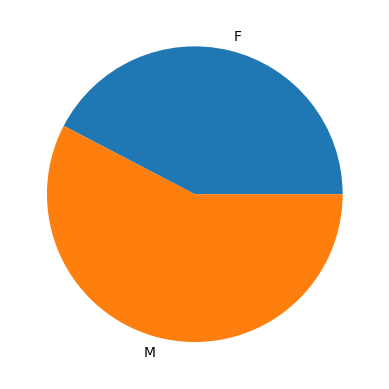

In [18]:
response = ask_df("Generate a pie chart to display average value of Walc for each Gender.")

Let's get the code LLM used for charting this plot.


#### Task 3

You can explore the impact of free time on grades based on the data.




> Entering new AgentExecutor chain...
Thought: To create box plots to analyze the relationship between 'freetime' and 'G3', we can use the `plot.boxplot()` function from the `matplotlib.pyplot` module. We'll group the data by 'freetime' and plot the 'G3' scores for each group.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df.boxplot(column='G3', by='freetime', vert=False)Axes(0.1,0.15;0.8x0.75)The box plots have been created to visualize the distribution of 'G3' scores for each level of 'freetime'. The x-axis represents the 'freetime' categories, and the y-axis shows the 'G3' scores. Each box plot provides a summary of the data in that group, with the box representing the interquartile range (IQR), the horizontal line inside the box indicating the median, and the whiskers extending to the minimum and maximum values within 1.5*IQR of the box.

Thought: To better understand the relationship between 'freetime' and 'G3', we can also calculate the mean 'G3' score

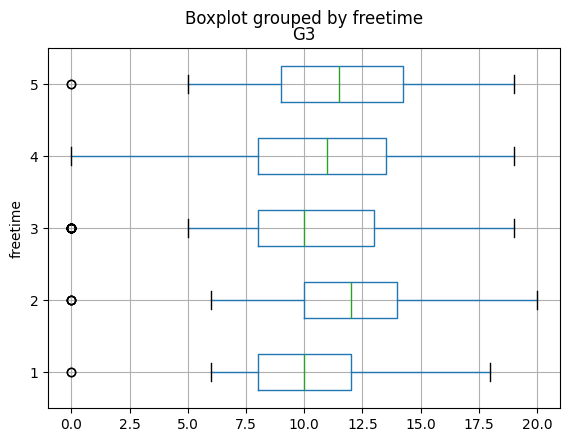

In [19]:
response = ask_df("Create box plots to analyze the relationship between 'freetime' (amount of free time) and 'G3' (final grade) across different levels of free time.")

Execute the code below to retrieve the Python script the LLM used for plotting.


#### Task 4

You can explore the effect of alcohol consumption on academic performance.




> Entering new AgentExecutor chain...


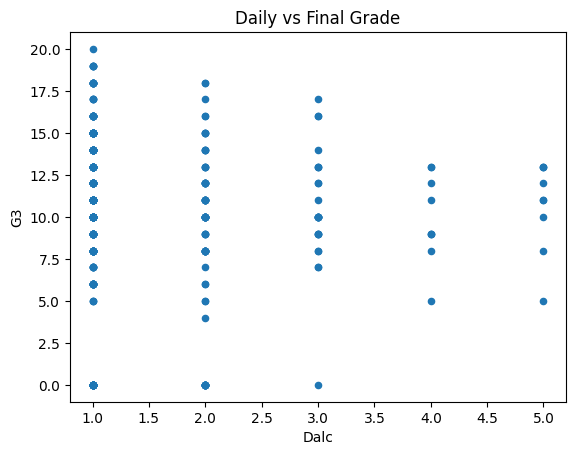

Thought: We need to create scatter plots to visualize the relationship between 'Dalc' and 'G3', and 'Walc' and 'G3' in the dataframe.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df.plot.scatter(x='Dalc', y='G3'); plt.title('Daily vs Final Grade'); plt.show(); 

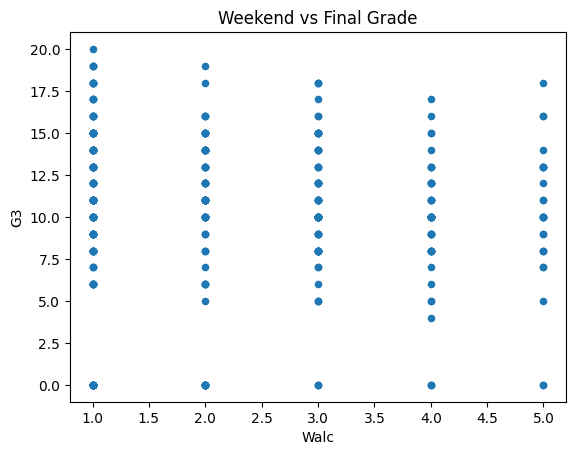

The scatter plot shows a positive correlation between 'Dalc' (daily alcohol consumption) and 'G3' (final grade). As daily alcohol consumption increases, the final grade tends to increase as well, although there is some scatter and not all points follow this trend.

Thought: Now let's examine the relationship between 'Walc' (weekend alcohol consumption) and 'G3'.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df.plot.scatter(x='Walc', y='G3'); plt.title('Weekend vs Final Grade'); plt.show(); The scatter plot shows a positive correlation between 'Walc' (weekend alcohol consumption) and 'G3' (final grade). As weekend alcohol consumption increases, the final grade tends to increase as well, although there is some scatter and not all points follow this trend.

Thought: We have now generated and examined the scatter plots for both 'Dalc' and 'Walc' against 'G3'. The plots suggest a positive correlation between alcohol consumption and final grade, but the relationship

In [20]:
response = ask_df("Generate scatter plots to examine the correlation between 'Dalc' (daily alcohol consumption) and 'G3', and between 'Walc' (weekend alcohol consumption) and 'G3'.")

Execute the code below to retrieve the Python script the LLM used for plotting.


# Exercises


### Exercise 1 - Relationship between parental education level and student grades




> Entering new AgentExecutor chain...
Thought: We need to create scatter plots to visualize the relationship between 'Medu' and 'G3', and 'Fedu' and 'G3'. We can use the `matplotlib` library in Python to generate these plots.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df.plot.scatter(x='Medu', y='G3', label='Mother's Education vs. Final Grade'); df.plot.scatter(x='Fedu', y='G3', label='Father's Education vs. Final Grade'); plt.legend(); plt.show()SyntaxError: invalid syntax. Perhaps you forgot a comma? (<unknown>, line 1)

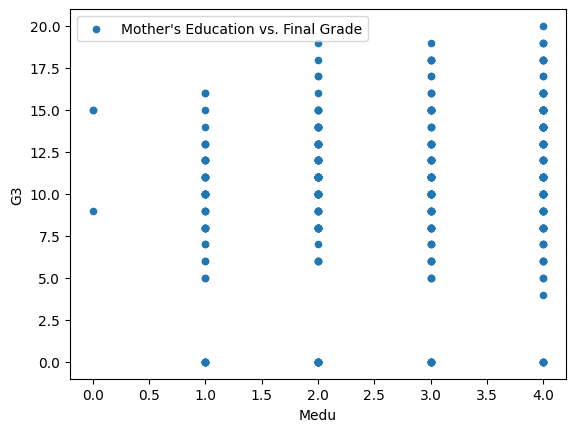

Thought: The error message indicates that there's a syntax issue in the code. Upon reviewing the input, I notice that the `label` parameter is not properly enclosed in quotes. 

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df.plot.scatter(x='Medu', y='G3', label='Mother\'s Education vs. Final Grade'); df.plot.scatter(x='Fedu', y='G3', label='Father\'s Education vs. Final Grade'); plt.legend(); plt.show()

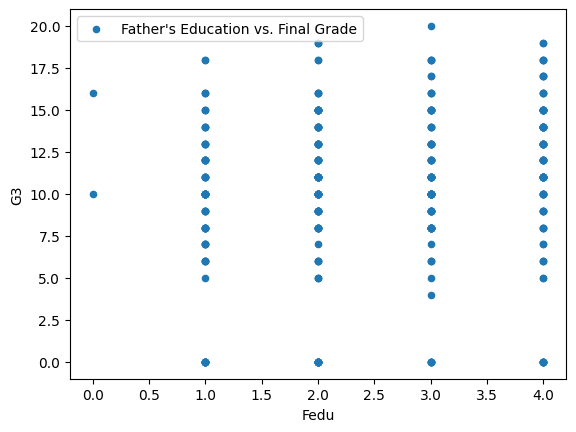

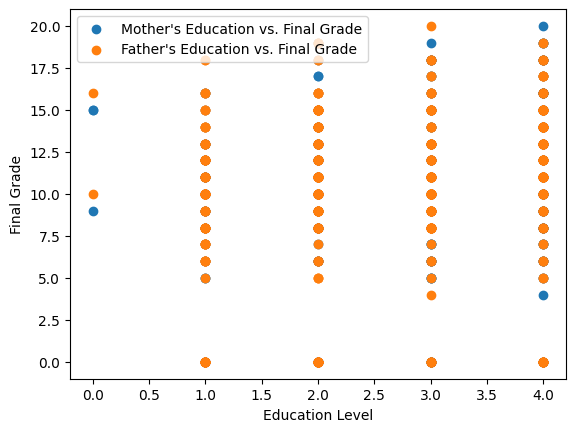

Thought: The code now looks correct, but it's not the most efficient way to generate the scatter plots. The `df.plot.scatter()` function is meant for plotting within a Jupyter notebook, not for standalone Python scripts. We can use `matplotlib` directly to create the plots.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; plt.scatter(df['Medu'], df['G3'], label='Mother\'s Education vs. Final Grade'); plt.scatter(df['Fedu'], df['G3'], label='Father\'s Education vs. Final Grade'); plt.xlabel('Education Level'); plt.ylabel('Final Grade'); plt.legend(); plt.show()Thought: The scatter plots have been generated successfully, showing the relationship between 'Medu' and 'G3', and 'Fedu' and 'G3'. The plots provide a visual representation of how the education levels of the mother and father are associated with the final grades of the students.

Final Answer: The scatter plots have been generated, showing the relationship between 'Medu' and 'G3', and 'Fedu' and 'G3'.

> Fi

In [21]:
# your code here

response = ask_df(
    "Generate scatter plots showing the relationship between "
    "'Medu' (mother's education level) and 'G3' (final grade), "
    "and between 'Fedu' (father's education level) and 'G3'. "
    
)

<details>
    <summary>Click here for Solution</summary>

```python

response = agent.invoke(
    "Generate scatter plots showing the relationship between "
    "'Medu' (mother's education level) and 'G3' (final grade), "
    "and between 'Fedu' (father's education level) and 'G3'. "
    
)

```

</details>


### Exercise 2 - Impact of internet access at home on grades




> Entering new AgentExecutor chain...
Thought: We need to group the students by their internet access and calculate the average final grade for each group. Then, we can create a bar plot to visualize the comparison.

Action: python_repl_ast
Action Input: df.groupby('internet')['G3'].mean().plot(kind='bar', title='Average Final Grades by Internet Access')Axes(0.125,0.11;0.775x0.77)The bar plot has been successfully created, showing the average final grades ('G3') for students with and without internet access at home. The x-axis represents the two groups ('yes' and 'no'), and the y-axis displays the average grades. The plot allows for a clear visual comparison of the average final grades between students with and without internet access at home.

Final Answer: The bar plot comparing average final grades ('G3') of students with and without internet access at home has been created, providing a visual representation of the difference in grades between the two groups.

> Finished chain.


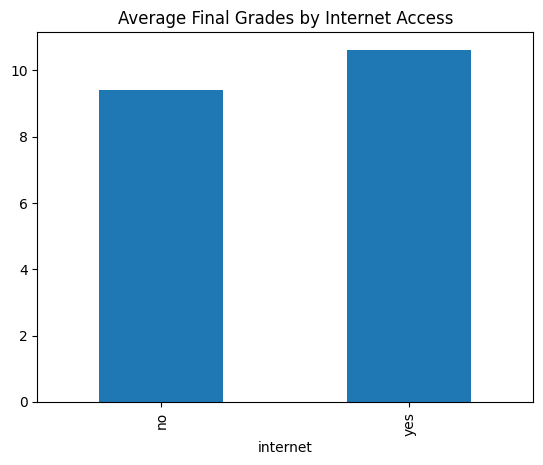

In [22]:
# your code here

response = ask_df("Use bar plots to compare the average final grades ('G3') of students with internet access at home versus those without ('internet' column).")

<details>
    <summary>Click here for a solution</summary>
    
```python

response = agent.invoke("Use bar plots to compare the average final grades ('G3') of students with internet access at home versus those without ('internet' column).")

```

</details>


### Exercise 3 - Explore LLM's code


Can you find what code the model used to generate the plot for exploring the relationship between absences and academic performance?

You could run the corresponding code and from the response chain, you could see the code used from charting.




> Entering new AgentExecutor chain...


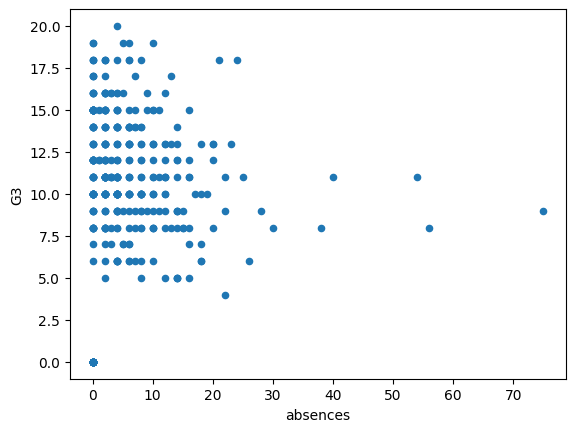

Thought: To plot a scatter plot showing the correlation between absences and final grades, we need to use the matplotlib library in Python. We'll select the 'absences' and 'G3' columns from the dataframe and then create the scatter plot.

Action: python_repl_ast
Action Input: import matplotlib.pyplot as plt; df.plot.scatter(x='absences', y='G3'); plt.show()The scatter plot has been generated, showing the relationship between the number of absences ('absences') and the final grades ('G3') of students. The plot provides a visual representation of the correlation between these two variables.

Thought: To better understand the correlation, we can also calculate the correlation coefficient (r-value) and the p-value, which will give us a numerical measure of the strength and statistical significance of the relationship.

Action: python_repl_ast
Action Input: import scipy.stats as stats; r, p = stats.pearsonr(df['absences'], df['G3'])The correlation coefficient (r) and p-value have been calcu

In [23]:
# your code here
esponse = ask_df("Plot a scatter plot showing the correlation between the number of absences ('absences') and final grades ('G3') of students.")

<details>
    <summary>Click here for a solution</summary>
    
```python

response = agent.invoke("Plot a scatter plot showing the correlation between the number of absences ('absences') and final grades ('G3') of students.")

for i in range(len(response['intermediate_steps'])):
    print(response['intermediate_steps'][i][0].tool_input.replace(';', '\n'))

```

</details>


## Authors


[Kang Wang](https://author.skills.network/instructors/kang_wang)

Kang Wang is a Data Scientist in IBM. He is also a PhD Candidate in the University of Waterloo.


[Wojciech Fulmyk](https://author.skills.network/instructors/wojciech_fulmyk) <br>
Wojciech "Victor" Fulmyk is a Data Scientist at IBM. He is also a PhD Candidate in Economics in the University of Calgary.


## Other contributors


[Ricky Shi](https://author.skills.network/instructors/ricky_shi) <br>
Ricky Shi is a data scientist at the Ecosystems Skills Network at IBM.


<!--## Change Log--!>


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-05-10|0.2|Kang Wang & Wojciech Fulmyk|Initial version created|
|2024-02-23|0.1|Elio Di Nino|Update library documentation|--!>



## Copyright © IBM Corporation. All rights reserved.
